<a href="https://colab.research.google.com/github/LizaMilovanova/Python-Project/blob/main/%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from google.colab import files
import io

In [22]:
# csv файл
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['Global YouTube Statistics (7).csv']), encoding='ISO-8859-1')

Saving Global YouTube Statistics.csv to Global YouTube Statistics (7).csv


In [23]:
# 5 перших рядків
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [31]:
# виводимо розміри датасету, перевіряємо наявність пропусків та дублікатів
print("Розмір датасету:", df.shape)
print("Кількість дублікатів:", df.duplicated().sum())
print("Кількість пропусків:", df.isna().sum())

Розмір датасету: (995, 28)
Кількість дублікатів: 0
Кількість пропусків: rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                       

In [32]:
# змінюємо тип даних пропусків і середнє значення за стовпцем
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean()).astype(float)

In [33]:
# повторно перевіряємо к-сть пропусків
print("Кількість пропусків:", df[numeric_cols].isna().sum())

Кількість пропусків: rank                                       0
subscribers                                0
video views                                0
uploads                                    0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_date                               0
Gross tertiary education enrollment (%)    0
Population                                 0
Unemployment rate                          0
Urban_population                           0
Latitude                                   0
Longitude                                  0
dtype: int64


In [35]:
# унікальні країни
unique_countries = df['Country'].nunique()
unique_countries

49

<Axes: title={'center': 'Pозподіл переглядів'}, ylabel='Frequency'>

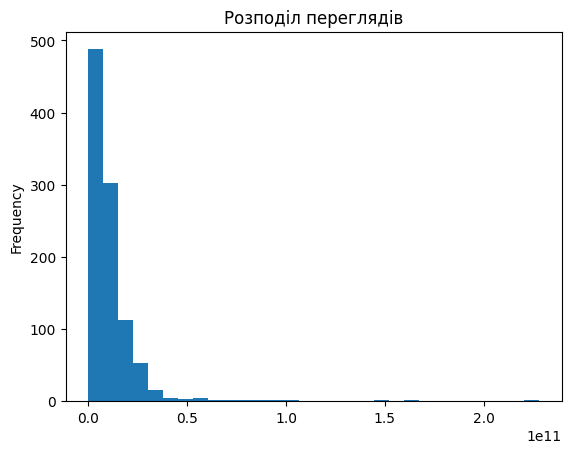

In [37]:
# діаграма розподілу переглядів
df['video views'].plot(kind = 'hist', title = 'Pозподіл переглядів', bins = 30)

In [41]:
# максимальна, мінімальна, середня к-сть переглядів
v_max = df['video views'].max()
v_min = df['video views'].min()
v_mean = df['video views'].mean()
print("максимальна к-сть переглядів:",v_max)
print("мінімальна к-сть переглядів:",v_min)
print("середня к-сть переглядів:",v_mean)

максимальна к-сть переглядів: 228000000000.0
мінімальна к-сть переглядів: 0.0
середня к-сть переглядів: 11039537052.03819


In [44]:
# країна, де найбільше відо було завантажено на ютуб
most_uploaded_country = df.groupby('Country')['uploads'].sum().idxmax()
most_uploaded_country

'India'

In [47]:
# відео з найбільшою і найменшою к-стю завантажень
max_uploads_title = df.loc[df['uploads'].idxmax(), 'Title']
min_uploads_title = df.loc[df['uploads'].idxmin(), 'Title']
print("Найбільша к-сть завантажень:",max_uploads_title)
print("Найменша к-сть завантажень:",min_uploads_title)


Найбільша к-сть завантажень: ABP NEWS
Найменша к-сть завантажень: Music
